- overall work flow of this project - we query relevant data from influx - this includes the mppt temperature sensors ad vehicle velocity
- data to be queried from open meteo - every 15 minutes is irradiance, wind speed, ambient temperature
- curve fit to find relevant coefficients needed for the faiman model


From InfluxDB, query data over the first 4 days of FSGP 2025.

In [3]:
from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone, tzinfo
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os


utc_offset_h = 5
start_utc = time(00 + utc_offset_h, 00, 00)  #querying is vancouver time, influxdb gives utc
stop_utc = time(00 + utc_offset_h, 00, 00)
date_start = date(2025, 7, 2)
date_stop = date(2025, 7, 6)
start_time = datetime.combine(date_start, start_utc, tzinfo=timezone.utc)
stop_time = datetime.combine(date_stop, stop_utc, tzinfo=timezone.utc)

client = query.DBClient()
temp_array_fsgp: TimeSeries = client.query_time_series(start_time, stop_time, field="MosfetTemperatureA")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")


alternate timezone calculations, by converting everything to vancouver time first, seems to yield better results but there is still a lag

In [4]:
from datetime import datetime, date, time, timedelta, timezone
import pytz

utc = pytz.timezone('UTC')

date_start = date(2025, 7, 1)
date_stop  = date(2025, 7, 6)


start_local = utc.localize(datetime.combine(date_start, time(0,0,0)))
stop_local  = utc.localize(datetime.combine(date_stop, time(0,0,0)))

#convert to utc
# start_utc = start_local.astimezone(pytz.utc)
# stop_utc  = stop_local.astimezone(pytz.utc)

print("start UTC:", start_utc)
print("stop UTC:", stop_utc)

client = query.DBClient()
temp_array_fsgp = client.query_time_series(start_utc, stop_utc, field="MosfetTemperatureA")
speed_kph_aliter       = client.query_time_series(start_utc, stop_utc, "MotorRotatingSpeed")


start UTC: 05:00:00
stop UTC: 05:00:00


ValueError: Datetime object must be timezone-aware.

In [ ]:
temp_array_fsgp._start = temp_array_fsgp._start + timedelta(hours = 7)

In [3]:
#save collected data of 15 minutes

import os
import dill

out_dir = os.path.join("../../motor_analysis", "data", "array_temperature_fsgp_2025-07-06")
mosfetA_file_aliter = os.path.join(out_dir, "mosfetA_aliter.bin")

os.makedirs(out_dir, exist_ok=True)

for filepath, data in zip([mosfetA_file_aliter],
                          [temp_array_fsgp]):
    with open(filepath, 'wb') as f:
        dill.dump(data, f)



#time zone matching conventions?? - add factor of 8 to open meteo maybe?

In [5]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 36.976,
	"longitude": 86.4491,
	"start_date": "2025-07-02",
	"end_date": "2025-07-07",
	"minutely_15": ["temperature_2m", "shortwave_radiation_instant", "wind_speed_10m"],
	"timezone": "auto",
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_shortwave_radiation_instant = minutely_15.Variables(1).ValuesAsNumpy()
minutely_15_wind_speed_10m = minutely_15.Variables(2).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}

minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["shortwave_radiation_instant"] = minutely_15_shortwave_radiation_instant
minutely_15_data["wind_speed_10m"] = minutely_15_wind_speed_10m

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print("\nMinutely15 data\n", minutely_15_dataframe)


Coordinates: 37.0°N 86.5°E
Elevation: 5139.0 m asl
Timezone: b'Asia/Shanghai'b'GMT+8'
Timezone difference to GMT+0: 28800s

Minutely15 data
                          date  temperature_2m  shortwave_radiation_instant  \
0   2025-07-01 16:00:00+00:00          -0.013                          0.0   
1   2025-07-01 16:15:00+00:00          -0.113                          0.0   
2   2025-07-01 16:30:00+00:00          -0.213                          0.0   
3   2025-07-01 16:45:00+00:00          -0.363                          0.0   
4   2025-07-01 17:00:00+00:00          -0.463                          0.0   
..                        ...             ...                          ...   
571 2025-07-07 14:45:00+00:00           1.587                          0.0   
572 2025-07-07 15:00:00+00:00           1.437                          0.0   
573 2025-07-07 15:15:00+00:00           1.287                          0.0   
574 2025-07-07 15:30:00+00:00           1.187                          0.0   
5

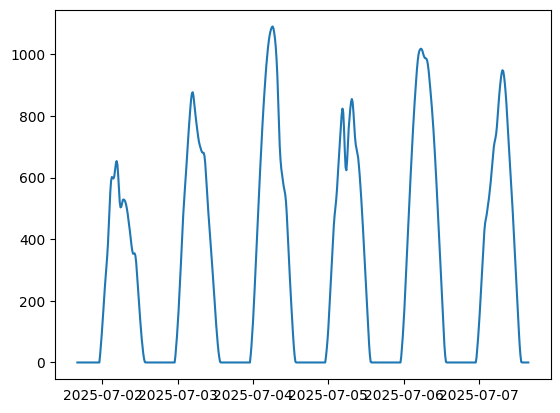

In [9]:
plt.plot(minutely_15_dataframe["date"],minutely_15_dataframe["shortwave_radiation_instant"])
plt.show()

kentucky is 3 hours ahead of vancouver

- some preprocessing, including:
- merging everything into a dataframe, with resampling influx data to match openmeteo's frequency

Plot some relevant data. this will further be used to generate the relevant coefficients

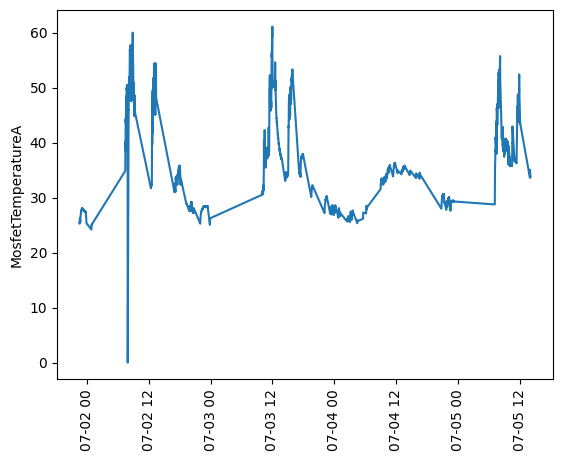

In [5]:
plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label="Array Temperature")
plt.ylabel("MosfetTemperatureA")

plt.tick_params("x", rotation=90)

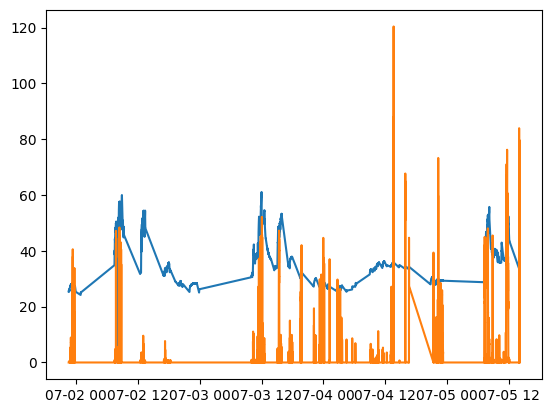

In [6]:

plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label="Array Temperature")
plt.plot(speed_kph.datetime_x_axis, speed_kph, label="Speed (kph)")

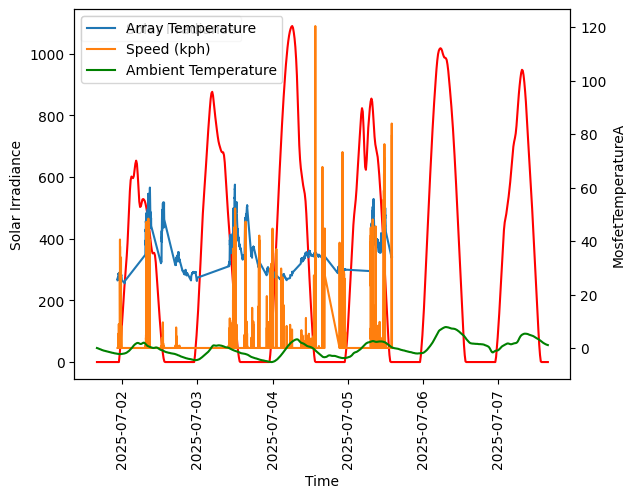

In [7]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label="Array Temperature")
plt.plot(speed_kph.datetime_x_axis, speed_kph, label="Speed (kph)")
plt.plot(minutely_15_data['date'], minutely_15_data['temperature_2m'], color='green', label="Ambient Temperature")
ax1.plot(minutely_15_data['date'], minutely_15_data['shortwave_radiation_instant'], color="red",
         label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

In [8]:
#there really isn't Influx data for dates after midday 5 July, so I see no reason to incorporate the OpenMeteo data after

In [9]:
#for easier access, im going to convert everything to a data frame after resampling.
import pandas as pd

#resampling influx data so that i can fit it with irradiance data (queried every 15 minutes)

ts = temp_array_fsgp
timestamps = pd.to_datetime(ts.datetime_x_axis, utc=True)
values = ts.data

df = pd.DataFrame({"value": values}, index=timestamps)
df_15m = df.resample("15T").mean()

df_15m["value_shifted"] = df_15m["value"].shift(-8)

print(df_15m.head())


                               value  value_shifted
2025-07-01 22:30:00+00:00  25.815057      24.492416
2025-07-01 22:45:00+00:00  27.457032      24.675352
2025-07-01 23:00:00+00:00  27.983232      25.388531
2025-07-01 23:15:00+00:00  27.667362      25.761946
2025-07-01 23:30:00+00:00  27.437863      26.135361


C:\Users\sanar\AppData\Local\Temp\ipykernel_32752\3978562244.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m = df.resample("15T").mean()


In [10]:
minutely_15_dataframe.head()
df_15min = minutely_15_dataframe[minutely_15_dataframe['date'] < '2025-07-06']

In [11]:
df_15min.tail()
weather_df = df_15min.copy()

#set datetime as index
weather_df["date"] = pd.to_datetime(weather_df["date"], utc=True)
weather_df = weather_df.set_index("date")
weather_df = weather_df.sort_index()


In [12]:
#sort indices
df_15m_copy = df_15m.copy().sort_index()
df_15m_copy["array_temperature"] = df_15m_copy["value_shifted"]
df_15m_copy = df_15m_copy.drop(columns=["value", "value_shifted"], errors="ignore")

weather_df = weather_df.sort_index()

#resampling for 15minute range
df_15m_copy.index = df_15m_copy.index.floor("15T")
weather_df.index = weather_df.index.floor("15T")
#ensure common timestamps
common_index = df_15m_copy.index.intersection(weather_df.index)

print("overlap start:", common_index.min())
print("overlap end:", common_index.max())
print("no of aligned points:", len(common_index))

#merging common timestamps
merged_df = pd.concat(
    [df_15m_copy.loc[common_index], weather_df.loc[common_index]],
    axis=1
)


overlap start: 2025-07-01 22:30:00+00:00
overlap end: 2025-07-05 14:00:00+00:00
no of aligned points: 351


C:\Users\sanar\AppData\Local\Temp\ipykernel_32752\1287101057.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m_copy.index = df_15m_copy.index.floor("15T")
C:\Users\sanar\AppData\Local\Temp\ipykernel_32752\1287101057.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  weather_df.index = weather_df.index.floor("15T")


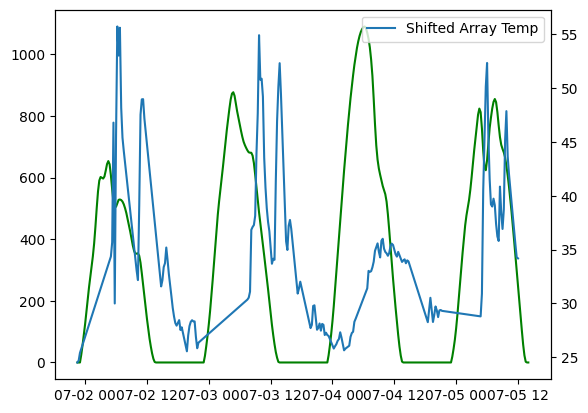

In [13]:

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()
plt.plot(merged_df["array_temperature"], label="Shifted Array Temp")
ax1.plot(merged_df["shortwave_radiation_instant"], label="Solar Irradiance", color = 'green')
plt.legend()
plt.show()


In [27]:
merged_df.dropna()

,array_temperature,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-01 22:30:00+00:00,24.492416,-2.163,0.000000,7.342588
2025-07-01 22:45:00+00:00,24.675352,-2.213,0.000000,7.280550
2025-07-01 23:00:00+00:00,25.388531,-2.263,0.000000,6.877790
2025-07-01 23:15:00+00:00,25.761946,-2.263,25.322779,6.489992
2025-07-01 23:30:00+00:00,26.135361,-2.263,55.886383,6.130579
...,...,...,...,...
2025-07-05 11:00:00+00:00,38.086209,2.387,443.232941,32.199379
2025-07-05 11:15:00+00:00,36.774658,2.337,395.066681,32.363979
2025-07-05 11:30:00+00:00,35.463106,2.237,346.080292,33.014175
2025-07-05 11:45:00+00:00,34.271664,2.137,297.251648,33.340351


In [15]:
merged_df = merged_df.rename(columns={'value': 'array_temperature'})

In [16]:
merged_df.head()

,array_temperature,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-01 22:30:00+00:00,24.492416,-2.163,0.000000,7.342588
2025-07-01 22:45:00+00:00,24.675352,-2.213,0.000000,7.280550
2025-07-01 23:00:00+00:00,25.388531,-2.263,0.000000,6.877790
2025-07-01 23:15:00+00:00,25.761946,-2.263,25.322779,6.489992
2025-07-01 23:30:00+00:00,26.135361,-2.263,55.886383,6.130579


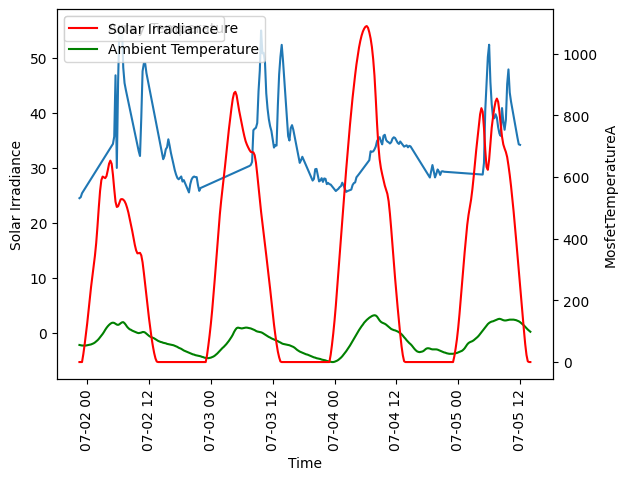

In [17]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

ax1.plot(merged_df['array_temperature'], label="Array Temperature")
ax1.plot(merged_df['temperature_2m'], color='green', label="Ambient Temperature")
plt.plot(merged_df['shortwave_radiation_instant'], color="red", label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

import the Physics Array Temperature Model for validation/sanity checks


In [23]:
from v4.array_temperature.arrayTemperatureModel import arrayTemperatureModel
import numpy as np
from scipy.optimize import curve_fit


def faiman_model(xdata, u0, u1):
    irradiance, ambient_temp, wind_speed = xdata
    model = arrayTemperatureModel(ambient_temperature=ambient_temp, irradiance=irradiance, wind_speed=wind_speed,
                                  thermal_loss_coefficient=u0, convective_loss_coefficient=u1)
    return model.calculateArrayTemperature()


#xdata, ydata
def fit_faiman(model, xdata, ydata, params):
    popt, _ = curve_fit(model, xdata, ydata, p0=params)

    return popt  # u0, u1


In [24]:
xdata = np.stack([merged_df['shortwave_radiation_instant'], merged_df['temperature_2m'], merged_df['wind_speed_10m']])
faiman_temp = np.array(faiman_model(xdata, 22, 0.8))

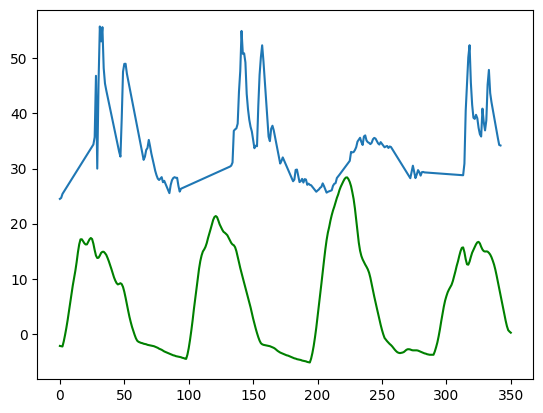

In [25]:
#comparing immediate, unfit results
plt.plot(np.array(merged_df['array_temperature']), label="Array Temperature")
plt.plot(faiman_temp, color="green", label="Modelled Temperature")

clearly, the faiman model peaks too early - which is due to its steady state nature. Also, to note that the MPPT sensors might have a ~5 C discrepancy, but that is iirelevant here as the model is currently, still quite close to ambient temperature. This indicates either an offset change or coefficients. Curve fitting might help for a more decisive result.

In [26]:
params = [22, 5.8]
xdata = np.stack([merged_df['shortwave_radiation_instant'], merged_df['temperature_2m'], merged_df['wind_speed_10m']])
popt = fit_faiman(faiman_model,
                  xdata,
                  merged_df['array_temperature'], params)

ValueError: array must not contain infs or NaNs

In [23]:
popt


array([17.38793587,  0.13933319])

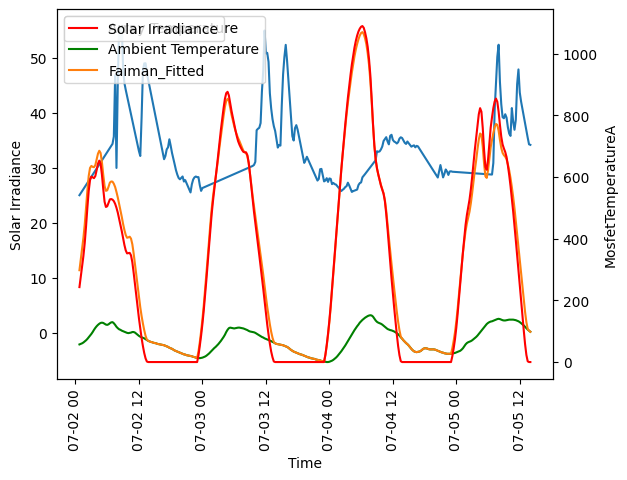

In [24]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

ax1.plot(merged_df['array_temperature'], label="Array Temperature")
ax1.plot(merged_df['temperature_2m'], color='green', label="Ambient Temperature")
ax1.plot(merged_df.index, faiman_model(xdata, *popt), label="Faiman_Fitted")
plt.plot(merged_df['shortwave_radiation_instant'], color="red", label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

including an offset and these particular parameters, closer to the curve fit seems to yield pretty consistent results with MPPT temperature. i will probably stick with these coefficients, and move onto the transient faiman model (parametrisation and a further curve fit)

Text(0.5, 1.0, 'offset_faiman_temperature')

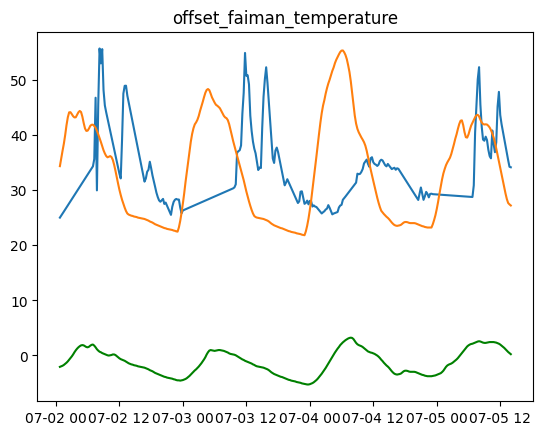

In [25]:
plt.plot(merged_df['array_temperature'], label="Array Temperature")
plt.plot(merged_df['temperature_2m'], color='green', label="Ambient Temperature")
plt.plot(merged_df.index, 27 + (faiman_model(xdata, *[22, 0.8])), label="Faiman_Fitted")
plt.title("offset_faiman_temperature")

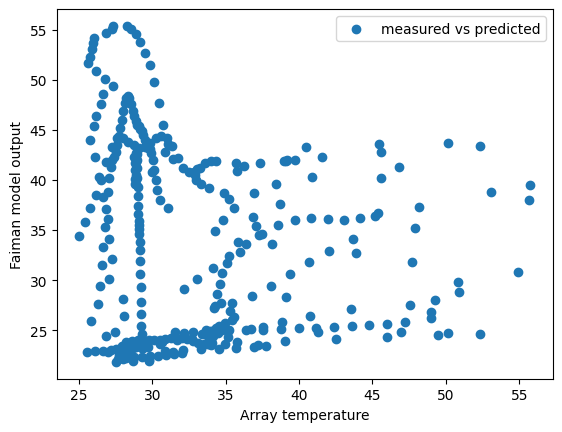

In [26]:
slope, intercept = popt
x = merged_df['temperature_2m']
y_pred = slope * x + intercept

plt.figure()
plt.scatter(merged_df['array_temperature'], faiman_model(xdata, 22, 0.8) + 27, label = "measured vs predicted")
#plt.plot(merged_df['array_temperature'], y_pred, linewidth=2)

plt.xlabel("Array temperature")
plt.ylabel("Faiman model output")
plt.legend()
plt.show()

# #plt.scatter(merged_df['array_temperature'],faiman_model(xdata, *[22, 0.8])+27)
#
# plt.plot(merged_df['array_temperature'], faiman_model(xdata, *[22, 0.8]) + 27,
#          label=f'Fitted Line: y = {slope:.2f}x + {intercept:.2f}', color='red', linewidth=2)

In [27]:
#trying an offset:

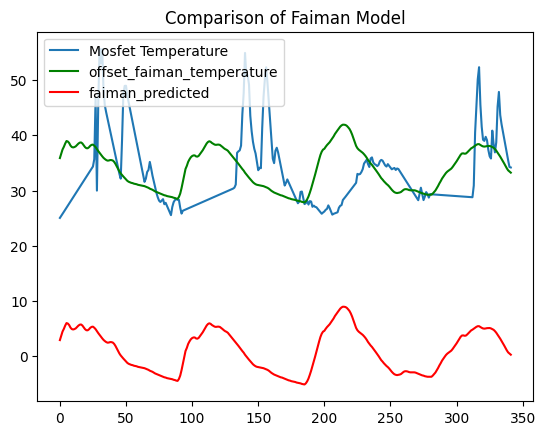

In [28]:
# initialparams, sourced from literature
plt.plot(np.array(merged_df['array_temperature']), label="Mosfet Temperature")
plt.plot(faiman_model(xdata, *params) + 33, color='green', label='offset_faiman_temperature')
plt.plot(faiman_model(xdata, *params), color='red', label='faiman_predicted')
plt.title("Comparison of Faiman Model")
plt.legend(loc="upper left")
plt.show()

 the faiman model doesn't seem to take into account the thermal mass i.e. the time it takes for the arrays themselves to heat up. following the appraoch in the paper linked, i used the thermal capacitance approach, namely considering the differential equation:

capacitance * dT/dt = G - (u0 + (u1*w) ) * (T_array - T_ambient)
 where capacitance is in terms of heat capacity per area (J/m^2 *K)

the analytical solution to this is:
T_array = T_steady-state - C(exp) * [-t *(u0/Ca + u1*w/Ca)]
and T_steady-state is just the output of the steady-state Faiman model.

in order to determine the capacitative parameter, there needs to be a recursive model. So assuming steady state condition at t - delt time, then compute the temperature for the next time step and integrate (a summation). Linearising the above differential yields:

t_array(i+1) = t_array(i) + del(t)/Ca * [G(i+0.5) - (u0 + u1*w(i+0.5) * (t_array(i) - t_array(i+0.5))]


T[i+1] = T[i] + dt/Ca * ( G[i] - (u0 + u1*w[i]) * (T[i] - Ta[i]) )



In [ ]:
# to dos - vector addition of car speed, and cleaning influx data for that. as of now, i am focusing on seeing if adding the thermal capacitance term might allow the faiman model's peaks to align with what we queried from influx.




In [ ]:
#some questions - does the temperature of the panels ever reach ambient temperature, even at night? if no, does that mean the car was always stored in room temperature competitions?